# Spatialize Evaluation Module

This notebook demonstrates the full functionality of `spatialize.evaluation`, which provides:

- **Metrics** — continuous (MAE, RMSE, R², bias, operational variants) and categorical (accuracy, precision, recall, F1)
- **Cross-validation** — leave-one-out and k-fold for any interpolation function
- **Benchmark utilities** — scipy and kriging wrappers, including auto-selection
- **Case studies** — `SyntheticScenario` (2D/3D, continuous/categorical) and `PrecipitationCaseStudy` (real 2.5D data)

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spatialize.gs.esi import esi_nongriddata, esi_griddata
from spatialize.gs.cat_esi import cat_esi_nongriddata
import spatialize.evaluation as ev
from spatialize.evaluation import (
    # Metrics — continuous
    error, absolute_error, bias,
    MAE, MSE, RMSE, R2,
    op_error, op_mae, op_rmse, op_mse,
    # Metrics — categorical
    accuracy, precision, recall, f1_score,
    # Cross-validation
    loo_validation, kfold_validation,
    # Benchmark
    scipy_prediction, auto_scipy_prediction, auto_krige,
    # Case studies
    SyntheticScenario, PrecipitationCaseStudy
)

---

# Part 1 — Continuous Metrics

In [2]:
true  = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
pred  = np.array([1.2, 1.8, 3.5, 3.9, 5.5])

print("Point-wise error  :", error(true, pred))
print("Absolute error    :", absolute_error(true, pred))
print()
print(f"Bias  : {bias(true, pred):.4f}  (positive → systematic over-prediction)")
print(f"MAE   : {MAE(true, pred):.4f}")
print(f"MSE   : {MSE(true, pred):.4f}")
print(f"RMSE  : {RMSE(true, pred):.4f}")
print(f"R²    : {R2(true, pred):.4f}")

Point-wise error  : [ 0.2 -0.2  0.5 -0.1  0.5]
Absolute error    : [0.2 0.2 0.5 0.1 0.5]

Bias  : 0.1800  (positive → systematic over-prediction)
MAE   : 0.3000
MSE   : 0.1180
RMSE  : 0.3435
R²    : 0.9410


## Operational (normalised) Metrics

Operational metrics divide by the dynamic range of the true values, making them comparable across datasets with different scales.

In [3]:
print(f"OpMAE   : {op_mae(true, pred):.4f}")
print(f"OpRMSE  : {op_rmse(true, pred):.4f}")
print(f"OpMSE   : {op_mse(true, pred):.4f}")

OpMAE   : 0.0750
OpRMSE  : 0.0859
OpMSE   : 0.0295


## NaN Handling

Metric functions silently ignore positions where either array is NaN.

In [4]:
true_nan = np.array([1.0, np.nan, 3.0, 4.0])
pred_nan = np.array([1.2,    2.0, 3.5, np.nan])

print(f"MAE with NaNs: {MAE(true_nan, pred_nan):.4f}  (only 2 valid pairs used)")

MAE with NaNs: 0.3500  (only 2 valid pairs used)


---

# Part 2 — Categorical Metrics

In [5]:
true_cat = np.array(["A", "B", "A", "C", "B", "A"])
pred_cat = np.array(["A", "B", "C", "C", "A", "A"])

print(f"Accuracy  : {accuracy(true_cat, pred_cat):.4f}")
print(f"Precision : {precision(true_cat, pred_cat):.4f}  (weighted)")
print(f"Recall    : {recall(true_cat, pred_cat):.4f}  (weighted)")
print(f"F1 score  : {f1_score(true_cat, pred_cat):.4f}  (weighted)")

Accuracy  : 0.6667
Precision : 0.7500  (weighted)
Recall    : 0.6667  (weighted)
F1 score  : 0.6667  (weighted)


### Averaging strategies

In [6]:
for avg in ('weighted', 'macro', 'micro'):
    print(f"  {avg:8s}  precision={precision(true_cat, pred_cat, average=avg):.3f}"
          f"  recall={recall(true_cat, pred_cat, average=avg):.3f}"
          f"  f1={f1_score(true_cat, pred_cat, average=avg):.3f}")

  weighted  precision=0.750  recall=0.667  f1=0.667
  macro     precision=0.722  recall=0.722  f1=0.667
  micro     precision=0.667  recall=0.667  f1=0.667


---

# Part 3 — Synthetic Case Studies

`SyntheticScenario` generates synthetic spatial data with known ground truth, enabling objective evaluation of interpolation methods.

## 3.1 2D Continuous Scenario (non-gridded)

In [7]:
scenario_2d = SyntheticScenario(
    n_dims=2,
    extent=[0, 100, 0, 100],
    griddata=False
)

points, values, xi, reference = scenario_2d.simulate_scenario(
    kind='cubic', n_samples=150, seed=42
)

print(f"Sample points : {points.shape}")
print(f"Target grid   : {xi.shape}")
print(f"Reference     : {reference.shape}")

Sample points : (150, 2)
Target grid   : (10201, 2)
Reference     : (10201,)


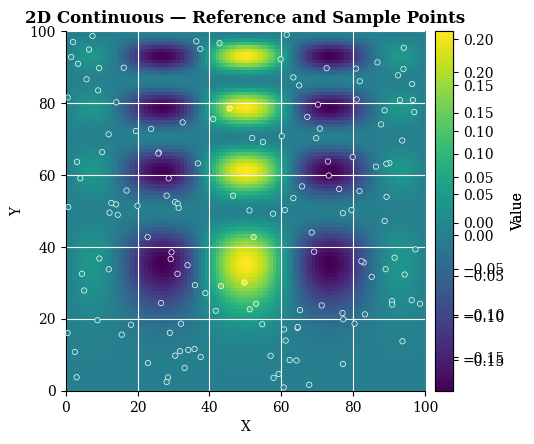

In [8]:
fig, ax = scenario_2d.plot_2d_scenario(
    points, values, xi, reference,
    theme='publication',
    title='2D Continuous — Reference and Sample Points',
)
plt.show()

## 3.2 2D Gridded Continuous Scenario

In [9]:
scenario_grid = SyntheticScenario(
    n_dims=2,
    extent=[0, 1, 0, 1],
    griddata=True,
    n_grid_points=60,
)

pts_g, vals_g, xi_g, ref_g = scenario_grid.simulate_scenario(
    kind='cubic', n_samples=150, seed=0
)

print(f"Grid xi shape : {xi_g.shape}  (2 × nx × ny)")
print(f"Reference     : {ref_g.shape}")

Grid xi shape : (2, 60, 60)  (2 × nx × ny)
Reference     : (60, 60)


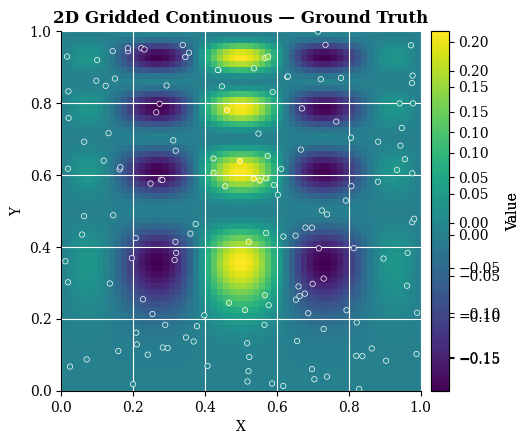

In [10]:
fig, ax = scenario_grid.plot_2d_scenario(
    pts_g, vals_g, xi_g, ref_g,
    theme='publication',
    title='2D Gridded Continuous — Ground Truth',
)
plt.show()

## 3.3 2D Nominal Categorical Scenario

In [11]:
scenario_cat = SyntheticScenario(
    categorical=True,
    n_grid_points=80,
)

pts_c, vals_c, xi_c, ref_c = scenario_cat.simulate_scenario(
    kind='nominal', n_samples=100, seed=7
)

print(f"Unique classes : {np.unique(ref_c)}")

Unique classes : ['A' 'B' 'C' 'D']


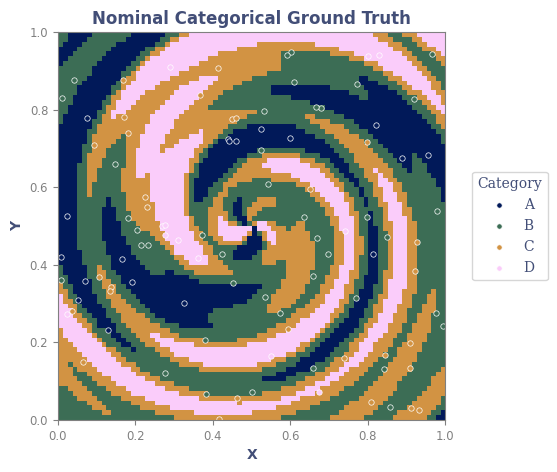

In [12]:
fig, ax = scenario_cat.plot_2d_scenario(
    pts_c, vals_c, xi_c, ref_c,
    title='Nominal Categorical Ground Truth',
    cmap='batlow'
)
plt.show()

## 3.4 2D Ordinal Categorical Scenario

In [13]:
scenario_ord = SyntheticScenario(categorical=True, n_grid_points=80)

pts_o, vals_o, xi_o, ref_o = scenario_ord.simulate_scenario(
    kind='ordinal', n_samples=150, seed=7
)

ordinal_labels = list(SyntheticScenario.ORDINAL_ORDER)  # ['Low', 'Medium', 'High']
print(f"Ordinal classes : {ordinal_labels}")
print(f"Class counts    : { {k: int((ref_o == k).sum()) for k in ordinal_labels} }")

Ordinal classes : ['Low', 'Medium', 'High']
Class counts    : {'Low': 2113, 'Medium': 2197, 'High': 2090}


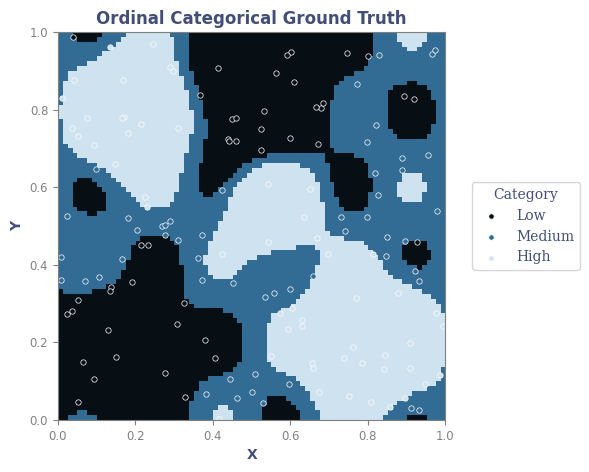

In [14]:
fig, ax = scenario_ord.plot_2d_scenario(
    pts_o, vals_o, xi_o, ref_o,
    nonnum_order=ordinal_labels,
    title='Ordinal Categorical Ground Truth',
)
plt.show()

## 3.5 3D Continuous Scenario

In [15]:
scenario_3d = SyntheticScenario(
    n_dims=3,
    extent=[0, 10, 0, 10, 0, 5],
    griddata=False,
    n_grid_points=(20, 20, 10),
)

pts_3, vals_3, xi_3, ref_3 = scenario_3d.simulate_scenario(
    kind='cubic', n_samples=400, seed=99
)

print(f"Sample points : {pts_3.shape}")
print(f"Target grid   : {xi_3.shape}  ({20*20*10} total locations)")

Sample points : (400, 3)
Target grid   : (4000, 3)  (4000 total locations)


## 3.6 Custom Function Scenario

You can inject your own ground-truth function via `custom_func`:

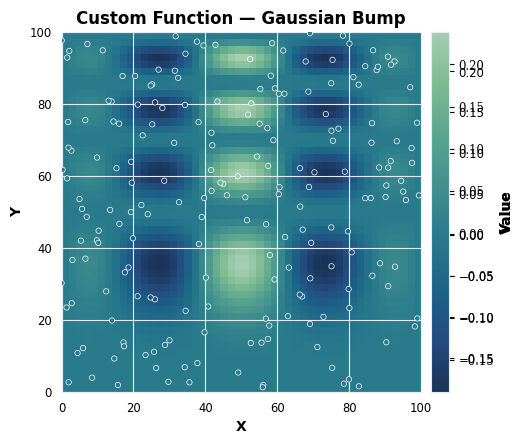

In [16]:
def gaussian_bump(x, y, cx=50, cy=50, sigma=15):
    return np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * sigma**2))

scenario_custom = SyntheticScenario(
    n_dims=2, extent=[0, 100, 0, 100], griddata=False, n_grid_points=50
)

pts_cu, vals_cu, xi_cu, ref_cu = scenario_custom.simulate_scenario(
    n_samples=200, seed=1,
    custom_func=gaussian_bump,
    custom_func_params={'cx': 50, 'cy': 50, 'sigma': 15},
)

fig, ax = scenario_custom.plot_2d_scenario(
    pts_cu, vals_cu, xi_cu, ref_cu,
    title='Custom Function — Gaussian Bump',
    theme='whitegrid',
)
plt.show()

---

# Part 4 — Cross-Validation

## 4.1 Leave-One-Out Validation

`loo_validation` evaluates any interpolation callable using LOO. The callable must have the signature `f(points, values, xi, **kwargs) -> array`.

In [17]:
def esi_predict(pts, vals, xi_, **kw):
    return esi_nongriddata(pts, vals, xi_, **kw).estimation()

loo_results = loo_validation(
    points, values,
    esi_predict,
    metrics=[MAE, RMSE, R2],
    # ESI kwargs:
    local_interpolator='idw',
    n_partitions=100,
    alpha=0.8,
    exponent=2.0,
)

print("LOO results:")
for name, val in loo_results.items():
    print(f"  {name:6s}: {val:.4f}")

LOO results:
  MAE   : 0.0222
  RMSE  : 0.0389
  R2    : 0.5616


### LOO with predictions array

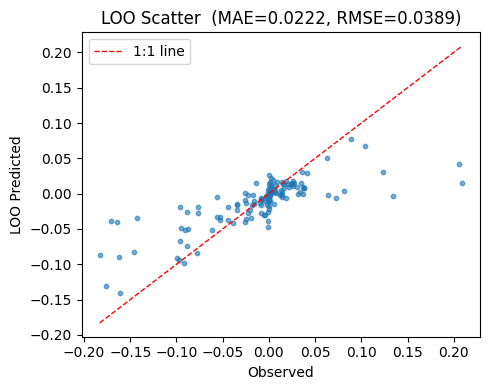

In [18]:
loo_results2, loo_preds = loo_validation(
    points, values,
    esi_predict,
    metrics=[MAE, RMSE],
    return_predictions=True,
    local_interpolator='idw',
    n_partitions=100,
    alpha=0.8,
    exponent=2.0,
)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(values, loo_preds, s=10, alpha=0.6)
ax.plot([values.min(), values.max()], [values.min(), values.max()],
        'r--', lw=1, label='1:1 line')
ax.set_xlabel('Observed')
ax.set_ylabel('LOO Predicted')
ax.set_title(f"LOO Scatter  (MAE={loo_results2['MAE']:.4f}, RMSE={loo_results2['RMSE']:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

## 4.2 K-Fold Cross-Validation

In [19]:
kfold_results = kfold_validation(
    points, values,
    esi_predict,
    k=5,
    metrics=[MAE, RMSE, R2],
    seed=42,
    local_interpolator='idw',
    n_partitions=100,
    alpha=0.8,
    exponent=2.0,
)

print("5-fold CV results:")
for name, val in kfold_results.items():
    print(f"  {name:6s}: {val:.4f}")

5-fold CV results:
  MAE   : 0.0233
  RMSE  : 0.0402
  R2    : 0.5307


### K-fold with out-of-fold predictions

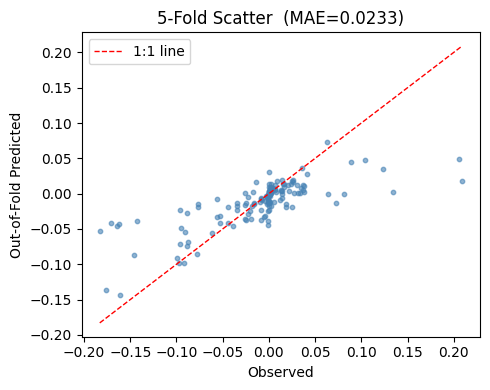

In [20]:
kfold_results2, kfold_preds = kfold_validation(
    points, values,
    esi_predict,
    k=5, seed=42,
    metrics=[MAE, RMSE],
    return_predictions=True,
    local_interpolator='idw',
    n_partitions=100,
    alpha=0.8,
    exponent=2.0,
)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(values, kfold_preds, s=10, alpha=0.6, color='steelblue')
ax.plot([values.min(), values.max()], [values.min(), values.max()],
        'r--', lw=1, label='1:1 line')
ax.set_xlabel('Observed')
ax.set_ylabel('Out-of-Fold Predicted')
ax.set_title(f"5-Fold Scatter  (MAE={kfold_results2['MAE']:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

### CV for categorical ESI

In [21]:
def cat_esi_predict(pts, vals, xi_, **kw):
    return cat_esi_nongriddata(pts, vals, xi_, **kw).estimation()

kfold_cat = kfold_validation(
    pts_c, vals_c,
    cat_esi_predict,
    metrics=[accuracy, f1_score],
    classifier='knn',
    n_partitions=100,
    alpha=0.8,
)

print("LOO categorical results:")
for name, val in kfold_cat.items():
    print(f"  {name:10s}: {val:.4f}")

LOO categorical results:
  accuracy  : 0.4400
  f1_score  : 0.4207


---

# Part 5 — Benchmark Utilities

## 5.1 Scipy Prediction

In [22]:
for method in ('nearest', 'linear', 'cubic'):
    est = scipy_prediction(points, values, xi, method=method)
    mae = MAE(reference, est)
    print(f"  scipy {method:8s}  MAE={mae:.4f}")

  scipy nearest   MAE=0.0279
  scipy linear    MAE=0.0255
  scipy cubic     MAE=0.0197


## 5.2 Auto Scipy (LOO-based Method Selection)

In [23]:
best_est = auto_scipy_prediction(points, values, xi, metric='mae')
print(f"\nBest scipy MAE on reference: {MAE(reference, best_est):.4f}")

Best method: 'cubic'  MAE = 0.0146

Best scipy MAE on reference: 0.0197


## 5.3 ESI vs Scipy Comparison

In [24]:
esi_result = esi_nongriddata(
    points, values, xi,
    local_interpolator='idw',
    n_partitions=200,
    alpha=0.8,
    exponent=2.0,
)
esi_est = esi_result.estimation()

comparison = {
    'scipy-nearest': MAE(reference, scipy_prediction(points, values, xi, method='nearest')),
    'scipy-linear' : MAE(reference, scipy_prediction(points, values, xi, method='linear')),
    'scipy-cubic'  : MAE(reference, scipy_prediction(points, values, xi, method='cubic')),
    'ESI-IDW'      : MAE(reference, esi_est),
}

print("\nMethod comparison (MAE vs ground truth):")
for method, mae in sorted(comparison.items(), key=lambda x: x[1]):
    print(f"  {method:15s}: {mae:.4f}")

finished 100% of 200 iterations ... 

done (elapsed time:  1s)

Method comparison (MAE vs ground truth):
  scipy-cubic    : 0.0197
  scipy-linear   : 0.0255
  scipy-nearest  : 0.0279
  ESI-IDW        : 0.0285


## 5.4 Kriging Prediction

In [25]:
kriging_est = auto_krige(points, values, xi, griddata=False, seed=42)
mae = MAE(reference, kriging_est)
print(f"Kriging MAE={mae:.4f}")

best_params =  {'method': 'ordinary', 'n_closest_points': 5, 'nlags': 8, 'variogram_model': 'gaussian'}
Kriging MAE=0.0220


---

# Part 6 — Precipitation Case Study (Real 2.5D Data)

`PrecipitationCaseStudy` wraps the Maipo Basin precipitation dataset. Sample points have 3D coordinates (UTM East, UTM North, elevation) and the target is precipitation at unsampled locations.

## 6.1 Loading and Visualizing Data

In [26]:
from spatialize.resources import ScientificColourMaps as SCM
case_study = PrecipitationCaseStudy(data_cmap=SCM.navia_r, locs_cmap=SCM.glasgow)

print(f"Dates: {case_study.dates}")

Dates: ['2018-07-04', '2018-07-05', '2018-07-06']


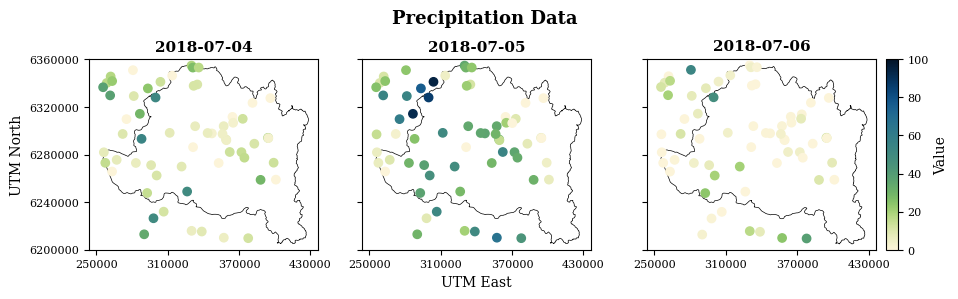

In [27]:
fig, axs = case_study.plot_input_data()
plt.tight_layout()
plt.show()

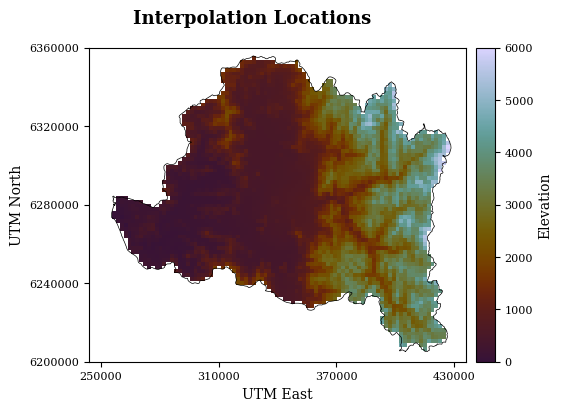

In [28]:
fig, ax = case_study.plot_interpolation_locations()
plt.show()

## 6.2 Running ESI for All Dates

In [29]:
# for ESI precision estimations
import spatialize.gs.esi.lossfunction as lf

points_pp, values_pp, xi_pp = case_study.model_inputs()

esi_results_df = case_study.locs.copy()
esi_results_df.columns = pd.MultiIndex.from_tuples(
    [(c, '') for c in esi_results_df.columns]
)

for date in case_study.dates:
    result = esi_nongriddata(
        points=points_pp[date],
        values=values_pp[date],
        xi=xi_pp,
        local_interpolator='idw',
        n_partitions=300,
        alpha=0.8,
        exponent=2.0,
        seed=42,
    )

    esi_results_df[(date, 'value')]     = result.estimation()
    esi_results_df[(date, 'precision')] = result.precision(lf.OperationalErrorLoss(values_pp[date].max()-values_pp[date].min()))


finished 100% of 300 iterations ... 

done (elapsed time:  0s)
finished 100% of 300 iterations ... 

done (elapsed time:  0s)
finished 100% of 300 iterations ... 

done (elapsed time:  0s)


## 6.3 Visualising ESI Results

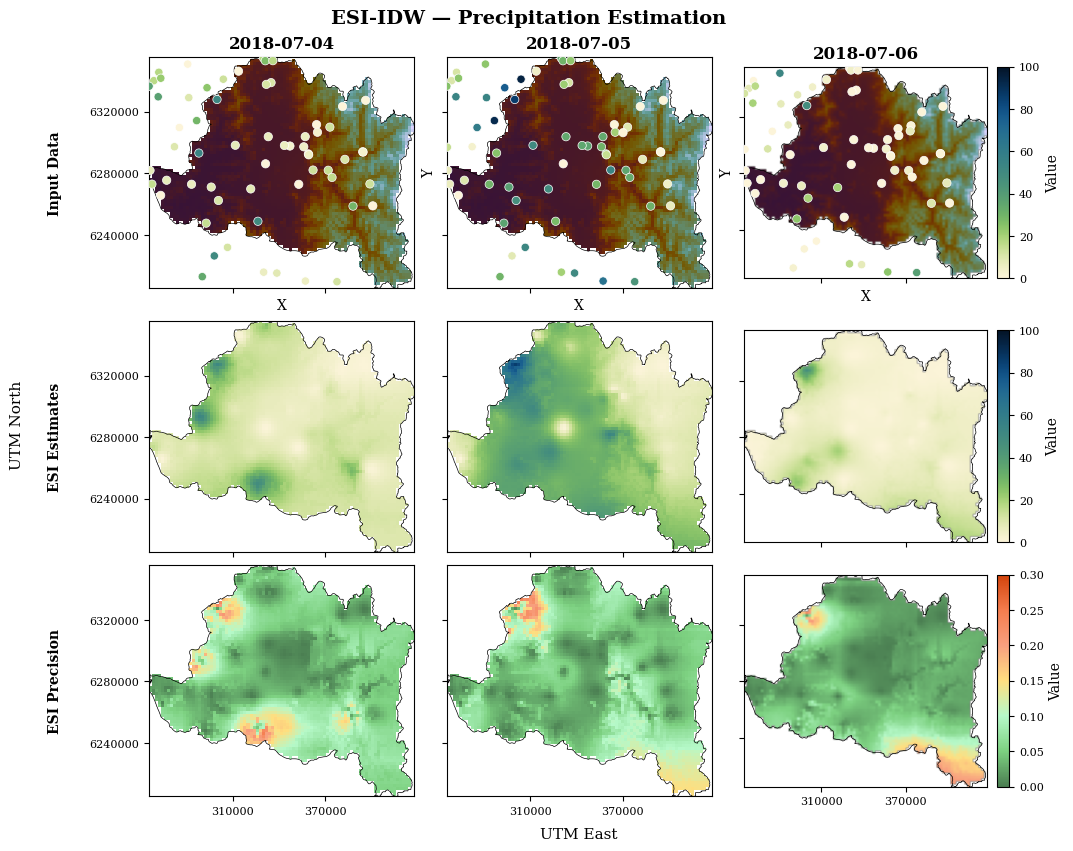

In [30]:
fig, axs = case_study.plot_esi_results(
    esi_results_df,
    parameters=None,
    local_interpolator='idw',
    precision_function='Operational MAE',
    fig_title='ESI-IDW — Precipitation Estimation',
)
plt.show()

## 6.4 Model Comparison

Compare ESI against scipy interpolation methods for a single date.

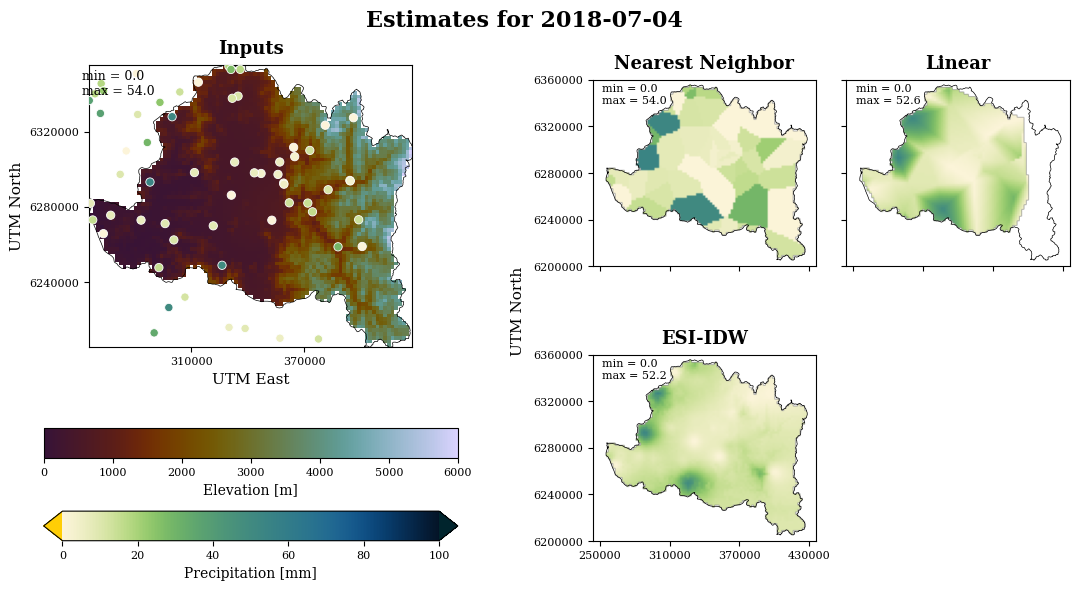

In [31]:
date = case_study.dates[0]

locs_xy = case_study.locs[['X', 'Y']].values

# Build a comparison results frame expected by plot_model_comparison
comp_df = case_study.locs.copy()

for method in ('nearest', 'linear'):
    est = scipy_prediction(
        points_pp[date][:, :2],   # use only x,y for scipy
        values_pp[date],
        locs_xy,
        method=method,
    )
    comp_df[(method, date, 'value')] = est

# ESI already computed above
comp_df[('esi', date, 'value')] = esi_results_df[(date, 'value')].values

fig, subfigs, ax0, axs_cmp = case_study.plot_model_comparison(
    comp_df, date=date,
    interpolators=['nearest', 'linear', 'esi'],
    names=['Nearest Neighbor', 'Linear', 'ESI-IDW'],
)
plt.show()

## 6.5 Quantitative Evaluation with `loo_validation`

We evaluate each interpolation method on the sample data with LOO CV.

In [32]:
date = case_study.dates[0]

def scipy_predict_2d(pts, vals, xi_, method='linear'):
    return scipy_prediction(pts[:, :2], vals, xi_[:, :2], method=method)

def esi_predict_3d(pts, vals, xi_, **kw):
    return esi_nongriddata(pts, vals, xi_, **kw).estimation()

methods = {
    'scipy-nearest': (scipy_predict_2d, {'method': 'nearest'}),
    'scipy-linear' : (scipy_predict_2d, {'method': 'linear'}),
    'ESI-IDW'      : (esi_predict_3d,   {
        'local_interpolator': 'idw',
        'n_partitions': 100,
        'alpha': 0.8,
        'exponent': 2.0,
    }),
}

print(f"LOO CV on {date}  ({len(values_pp[date])} samples)\n")
for name, (fn, kwargs) in methods.items():
    res = loo_validation(
        points_pp[date] if name == 'ESI-IDW' else points_pp[date],
        values_pp[date],
        fn,
        metrics=[MAE, RMSE, R2],
        **kwargs,
    )
    print(f"  {name:15s}  MAE={res['MAE']:.2f}  RMSE={res['RMSE']:.2f}  R²={res['R2']:.3f}")

LOO CV on 2018-07-04  (61 samples)

  scipy-nearest    MAE=11.27  RMSE=16.11  R²=-0.409
  scipy-linear     MAE=10.97  RMSE=15.69  R²=-0.269
  ESI-IDW          MAE=9.25  RMSE=13.18  R²=0.057


---

# Summary

| Module component | Demonstrated in |
|---|---|
| `error`, `absolute_error`, `bias` | Part 1 |
| `MAE`, `MSE`, `RMSE`, `R2` | Part 1 |
| `op_mae`, `op_rmse`, `op_mse` | Part 1 |
| NaN-safe metric behaviour | Part 1 |
| `accuracy`, `precision`, `recall`, `f1_score` | Part 2 |
| `SyntheticScenario` — 2D continuous (gridded / non-gridded) | Part 3 |
| `SyntheticScenario` — nominal categorical | Part 3 |
| `SyntheticScenario` — ordinal categorical | Part 3 |
| `SyntheticScenario` — 3D continuous | Part 3 |
| `SyntheticScenario` — custom function | Part 3 |
| `loo_validation` — continuous | Part 4 |
| `loo_validation` — categorical | Part 4 |
| `kfold_validation` — continuous | Part 4 |
| `scipy_prediction` | Part 5 |
| `auto_scipy_prediction` | Part 5 |
| `PrecipitationCaseStudy` — data loading and plots | Part 6 |
| `PrecipitationCaseStudy.plot_esi_results` | Part 6 |
| `PrecipitationCaseStudy.plot_model_comparison` | Part 6 |
| `loo_validation` on real data | Part 6 |